<a href="https://colab.research.google.com/github/Alaebal/lungcancer-app/blob/main/ai_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import os

# 1. Configuration des chemins
base_path = '/content/drive/MyDrive/cancer de poumon'
train_path = os.path.join(base_path, 'train')
valid_path = os.path.join(base_path, 'valid')

# 2. Préparation des images (Redimensionnement et Normalisation)
# On redimensionne à 224x224 car c'est la taille standard pour l'IA MobileNetV2
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary') # Binary car on a 2 classes : Cancer ou Sain

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary')

# 3. Création du modèle IA (Transfer Learning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # On garde les connaissances de base de l'IA

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # Sortie : 0 (Sain) à 1 (Cancer)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Lancement de l'entraînement
print("L'IA commence à apprendre... Patientez quelques minutes.")
history = model.fit(
    train_generator,
    epochs=10, # On fait 10 passages sur les photos
    validation_data=valid_generator
)

# 5. Sauvegarder le modèle pour ne pas le perdre
model.save('mon_ia_cancer.h5')
print("Entraînement terminé et modèle sauvegardé !")

Found 566 images belonging to 2 classes.
Found 68 images belonging to 2 classes.
L'IA commence à apprendre... Patientez quelques minutes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8021 - loss: 0.4412 - val_accuracy: 0.9853 - val_loss: 0.1385
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9197 - loss: 0.2173 - val_accuracy: 1.0000 - val_loss: 0.0739
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9503 - loss: 0.1284 - val_accuracy: 1.0000 - val_loss: 0.0574
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9616 - loss: 0.1193 - val_accuracy: 0.9853 - val_loss: 0.0521
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9724 - loss: 0.0893 - val_accuracy: 0.9853 - val_loss: 0.0478
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9982 - loss: 0.0628 - val_accuracy: 0.9853 - val_loss: 0.0464
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9955 - loss: 0.0549 - val_accuracy: 0.9853 - val_loss: 0.0448
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9926 - loss: 0.0548 - val_accuracy: 0.9853 - val_loss:

Entraînement terminé et modèle sauvegardé !


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
base_path = '/content/drive/MyDrive/cancer de poumon'
train_path = os.path.join(base_path, 'train')
valid_path = os.path.join(base_path, 'valid')

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
import os
import shutil

# On définit les 3 parties du projet
parties = ['train', 'valid', 'test']

for p in parties:
    # Chemin vers le dossier sain de chaque partie
    path_sain = f'/content/drive/MyDrive/cancer de poumon/{p}/sain'

    # On vérifie si le sous-dossier 'normal' existe à l'intérieur
    sub_normal = os.path.join(path_sain, 'normal')

    if os.path.exists(sub_normal):
        files = os.listdir(sub_normal)
        for f in files:
            # On déplace chaque photo vers le dossier parent 'sain'
            shutil.move(os.path.join(sub_normal, f), os.path.join(path_sain, f))

        # On supprime le dossier 'normal' maintenant qu'il est vide
        os.rmdir(sub_normal)
        print(f"✅ Dossier {p}/sain nettoyé avec succès !")
    else:
        print(f"ℹ️ Le dossier {p}/sain semble déjà prêt ou le chemin est différent.")

ℹ️ Le dossier train/sain semble déjà prêt ou le chemin est différent.
ℹ️ Le dossier valid/sain semble déjà prêt ou le chemin est différent.
ℹ️ Le dossier test/sain semble déjà prêt ou le chemin est différent.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary') # Binary car on a 2 classes : Cancer ou Sain


Found 566 images belonging to 2 classes.


In [ ]:
valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary')

Found 68 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # Sortie : 0 (Sain) à 1 (Cancer)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
print("L'IA commence à apprendre... Patientez quelques minutes.")
history = model.fit(
    train_generator,
    epochs=10, # On fait 10 passages sur les photos
    validation_data=valid_generator
)

L'IA commence à apprendre... Patientez quelques minutes.
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7406 - loss: 0.5046 - val_accuracy: 0.9706 - val_loss: 0.1591
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9289 - loss: 0.2124 - val_accuracy: 1.0000 - val_loss: 0.0839
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9572 - loss: 0.1418 - val_accuracy: 1.0000 - val_loss: 0.0621
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9744 - loss: 0.1264 - val_accuracy: 0.9853 - val_loss: 0.0549
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9733 - loss: 0.0997 - val_accuracy: 0.9853 - val_loss: 0.0509
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9689 - loss: 0.0924 - val_accuracy: 0.9853 - val_loss: 0.0474
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9907 - loss: 0.0682 - val_accuracy: 0.9853 - val_loss: 0.0462
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy:

In [ ]:
model.save('mon_ia_cancer.h5')

# 2. Téléchargement automatique sur ton ordinateur
from google.colab import files
files.download('mon_ia_cancer.h5')

print("Regarde tes téléchargements, le fichier arrive !")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Regarde tes téléchargements, le fichier arrive !


In [ ]:
model.save('/content/drive/MyDrive/mon_ia_cancer.h5')

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf


path = '/content/drive/MyDrive/mon_ia_cancer.h5'

model = tf.keras.models.load_model(path)
print("Modèle chargé avec succès depuis le Drive !")

Modèle chargé avec succès depuis le Drive !


In [ ]:
img_path = "/content/drive/MyDrive/cancer de poumon/test/cancer/000108 (3).png"

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Ajouter une dimension pour l'IA
img_array /= 255.0 # Normalisation

In [ ]:
prediction = model.predict(img_array)
pourcentage = prediction[0][0] * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Sévérité : MODÉRÉE
Résultat : CANCER DÉTECTÉ (81.02%)


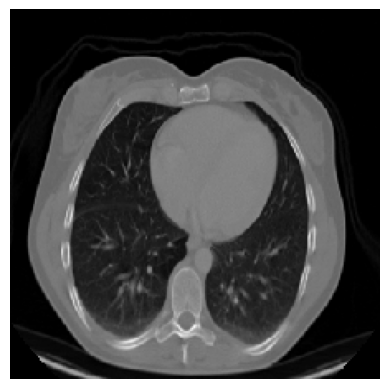

In [ ]:
plt.imshow(img)
plt.axis('off')

if pourcentage < 50: # < 50 signifie que l'IA est proche de 0 (donc Cancer)
    resultat_final = "CANCER DÉTECTÉ"
    confiance = 100 - pourcentage # On inverse pour avoir un score logique
    if confiance > 85:
      print("Sévérité : ÉLEVÉE")
    else:
        print("Sévérité : MODÉRÉE")
else:
    resultat_final = "POUMONS SAINS"
    confiance = pourcentage

print(f"Résultat : {resultat_final} ({confiance:.2f}%)")

plt.show()

In [ ]:
print(train_generator.class_indices)

{'cancer': 0, 'sain': 1}


In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 88.3 MB/s eta 0:00:00


In [ ]:
# Cette cellule doit être dans Colab
%%writefile app.py
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np
import os

st.set_page_config(page_title="Détecteur Cancer Poumon", page_icon="🫁")

st.title("🫁 IA de Diagnostic : Cancer du Poumon")
st.write("Ce projet utilise un réseau de neurones (MobileNetV2) pour analyser les scans CT.")

MODEL_PATH = "/content/drive/MyDrive/mon_ia_cancer.h5"

@st.cache_resource
def load_my_model():
    if not os.path.exists(MODEL_PATH):
        st.error("❌ Le fichier modèle n'existe pas dans le Drive.")
        return None
    try:
        model = tf.keras.models.load_model(MODEL_PATH, compile=False)
        return model
    except Exception as e:
        st.error(f"❌ Erreur chargement modèle : {e}")
        return None

model = load_my_model()

st.markdown("---")

uploaded_file = st.file_uploader(
    "Choisissez un scan (JPG, PNG, JPEG)...",
    type=["jpg", "png", "jpeg"]
)

if uploaded_file is not None and model is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption="Scan téléchargé", use_container_width=True)

    with st.spinner("Analyse en cours..."):
        img = image.convert("RGB")
        img = img.resize((224, 224))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)
        score_brut = prediction[0][0]

        probabilite_cancer = (1 - score_brut) * 100

        st.subheader("Résultat du diagnostic :")
        if probabilite_cancer > 50:
            st.error("⚠️ CANCER DÉTECTÉ")
            st.write(f"Probabilité de malignité : **{probabilite_cancer:.2f}%**")
            if probabilite_cancer > 85:
                st.warning("Degré de sévérité : ÉLEVÉ")
            else:
                st.info("Degré de sévérité : MODÉRÉ")
        else:
            st.success("✅ POUMONS SAINS")
            st.write(f"Risque détecté : **{probabilite_cancer:.2f}%**")

st.markdown("---")
st.caption("Outil d'aide à la décision médicale - Projet Étudiant - Février 2026")


Overwriting app.py


In [ ]:
# 1. Tue les anciens processus pour repartir à zéro
!pkill streamlit
!pkill npx

# 2. Relance Streamlit en arrière-plan
import subprocess
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

# 3. Génère un NOUVEAU lien
print("Ton mot de passe (IP) à copier :")
!curl ipv4.icanhazip.com
print("\nClique sur ce nouveau lien :")
!npx localtunnel --port 8501

Ton mot de passe (IP) à copier :
34.57.44.214

Clique sur ce nouveau lien :
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://warm-bars-flow.loca.lt
^C


Overwriting app.py


In [ ]:
!npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://heavy-paws-lay.loca.lt
^C


In [ ]:
!pip install -q streamlit

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.57.44.214:8501

your url is: https://upset-wombats-shake.loca.lt
2026-02-17 16:57:47.484830: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771347467.510953   22662 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771347467.519198   22662 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771347467.538676   22662 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771347467